<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day23_practice1_YOLO%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%A6%9D%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 모델이 못 잡는 큰 포트홀을 보강
# Roboflow로 라벨링한 seed 이미지를 Affine(확대, 좌우, 상하)과 Crop + Resize(포트홀 주변을 잘라 크게)로 데이터 증강
# Affine scale은 '화면 전체'를 당기고, Crop+Resize는 '포트홀 자체'를 크게 만든다
# bbox_params 덕분에 이미지가 변형될 때 바운딩 박스가 함께 변환된다(라벨 재작업 불필요)

In [18]:
# 셀 1. 준비
!pip install -q albumentations # 데이터 증강 라이브러리
import os, glob
import cv2 # OpenCV, 이미지를 numpy 배열로 읽고 쓴다
import albumentations as A
import matplotlib.pyplot as plt
import random


from google.colab import drive
drive.mount('/content/drive')

print("albumentations", A.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
albumentations 2.0.8


In [5]:
# 경로, seed 탐색
DRIVE_ROOT = "/content/drive/MyDrive/KWU/DL/roadhazard"
SRC = f"{DRIVE_ROOT}/dataset/roboflow_big" # Roboflow로 라벨링한 images/labels
OUT = f"{DRIVE_ROOT}/dataset_aug" # 증강 결과
os.makedirs(f"{OUT}/images/train", exist_ok=True)
os.makedirs(f"{OUT}/labels/train", exist_ok=True)
exts = ("*.jpg", "*.jpeg", "*.png")
seeds = []
for e in exts:
  seeds += glob.glob(f"{SRC}/**/images/{e}", recursive=True)
  seeds += glob.glob(f"{SRC}/images/{e}")
seeds = sorted(set(seeds))
assert seeds, f"sees 이미지가 없습니다: {SRC} (Roboflow YOLOv8 export를 여기에 두세요)"
print(f"seed 이미지 {len(seeds)}장 발견")

seed 이미지 11장 발견


In [6]:
# 셀 2. 두 가지 변형 함수 정의
# SCALE, X_SHIFT, Y_SHIFT의 곱(조합)으로 Affine 변형이
# CROP_MARGINS, X_SHIFT, Y_SHIFT의 곱으로 Crop 변형이 생성된다
SCALES = [1.0, 1.4, 1.9, 2.5] # Affine의 확대 배율
X_SHIFT = [-0.30, -0.15, 0.0, 0.15, 0.30] # 좌우 이동 비율, -왼쪽, +오른쪽
Y_SHIFT = [-0.15, 0.0, 0.15] # 상하 이동 비율, -위, +아래
CROP_MARGINS = [1.6, 2.4, 3.4] # Crop 창이 '박스의 몇 배'인지, 작을수록 포트홀을 꽉 채워 '더 크게' 확대
IMG_H, IMG_W = 768, 1408 # 결과 이미지의 높이, 너비
MIN_VIS = 0.25 # 변형 후 원래의 25% 미만만 남은 박스는 자동 제거
EXTRA = [
    A.HorizontalFlip(p=0.5), # 좌우 반전
    A.RandomBrightnessContrast(0.25, 0.25, p=0.6), # 밝기/대비
    A.ColorJitter(0.2, 0.2, 0.2, 0.05, p=0.4), # 색감을 섞기
]

In [24]:
def read_yolo(lp):
  rows=[]
  for line in open(lp): # 라벨 파일 경로
    s = line.split()
    # if len(s) == 5: rows.append([int(float(s[0])), *map(float, s[1:])])
    if len(s)==5: rows.append((int(float(s[0])),*map(float, s[1:])))
  return rows #[(0, 0.5, 0.6, 0.2, 0.15), ...]

def label_path(ip): # 이미지 경로
  return os.path.splitext(ip.replace("/images/", "/labels/"))[0]+".txt" # 이미지와 '같은 이름의' 라벨 경로를 만든다

# affine을 사용한 증강
def affine_variant(img, boxes, cls, s, dx, dy): # img = 이미지배열, boxes = 박스들, cls = 클래스들, s = 배율, dx/dy = 이동
  tf = A.Compose(
      [A.Affine(scale = s, translate_percent={"x": dx, "y": dy}, keep_ratio=True, p=1.0)] + EXTRA,
      bbox_params=A.BboxParams(format="yolo", label_fields=["cls"], min_visibility=MIN_VIS) # 박스도 함께 변환
  )
  return tf(image=img, bboxes=boxes, cls=cls) # {"image", "bboxes", "cls"}

# Crop + Resize를 사용한 증강
def crop_zoom_variant(img, boxes, cls, margin, dx, dy): # Crop+Resize 변형
  H, W = img.shape[:2] # H,W 만 (원래 (H,W,C))
  pot = [k for k, c in enumerate(cls) if c == 0] # 클래스가 0(pothole)인 박스의 인덱스
  if not pot: return None
  cx, cy, bw, bh = boxes[random.choice(pot)] # 포트홀 인덱스 중 하나 무작위 선택
  cx += dx * bw; cy += dy * bh # crop 중심을 포트홀 크기에 비례해 좌우/상하로 조금 옯겨 '위치'도 다양화
  hw, hh = bw * margin / 2, bh * margin / 2 # crop 창의 반폭/반높이
  x1, y1 = int(max(0, (cx-hw)*W)), int(max(0, (cy-hh)*H)) # 정수로 정규화, 좌상단 픽셀
  x2, y2 = int(min(W, (cx+hw)*W)), int(min(H, (cy+hh)*H)) # 우하단 픽셀
  if x2-x1 < 20 or y2-y1 < 20: return None # crop 영역이 너무 작으면 스킵
  tf = A.Compose(
      [A.Crop(x_min=x1, y_min=y1, x_max=x2, y_max=y2), A.Resize(IMG_H, IMG_W)] + EXTRA, # 잘라내고 원래 크기로 키움
      bbox_params=A.BboxParams(format="yolo", label_fields=["cls"], min_visibility=MIN_VIS)
  )
  return tf(image=img, bboxes=boxes, cls=cls) # {"image", "bboxes", "cls"}

In [25]:
# 셀 3. 증강 생성 → dataset_aug에 저장
# seed 이미지마다 Affine 스윕과 Crop 스윕을 돌려 저장

def _save(out, tag): # 증강 결과를 저장
  if not out or not out["bboxes"] or not any(c == 0 for c in out["cls"]):
    return 0 # 저장 실패
  base = f"aug_{tag}"
  cv2.imwrite(f"{OUT}/images/train/{base}.jpg", out["image"]) # 이미지 저장
  with open(f"{OUT}/labels/train/{base}.txt", "w") as f: # 라벨 저장
    for (cx, cy, w, h) in out["bboxes"]:
      f.write(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n") # YOLO 라벨 형식
  return 1 # 저장 성공

made = 0
for ip in seeds: # seed 이미지 경로마다
  lp = label_path(ip) # 짝 라벨 경로
  if not os.path.exists(lp):
    print("라벨 없음:", os.path.basename(ip)); continue
  img = cv2.imread(ip) # ndarray(H, W, 3)
  rows = read_yolo(lp) # [(cls, cx, cy, w, h)]
  boxes = [[cx, cy, w, h] for _, cx, cy, w, h in rows] # 좌표만
  cls = [c for c, *_ in rows] # 클래스만
  if img is None or not boxes:
    continue
  stem = os.path.splitext(os.path.basename(ip))[0] # 확장자 뗀 파일명

  # Affine: 확대×좌우×상하
  for s in SCALES:
    for dx in X_SHIFT:
      for dy in Y_SHIFT:
        out = affine_variant(img, boxes, cls, s, dx, dy) # 이 조합 한 가지로 증강 1개 생성
        made += _save(out, f"{stem}_A_s{int(s*100)}_x{int(dx*100):+d}_y{int(dy*100):+d}") # 파일명에 변형 정보를 담아

  # Crop + Resize: crop 확대 ×좌우 ×상하 (포트홀을 크게)
  for m in CROP_MARGINS:
    for dx in X_SHIFT:
      for dy in Y_SHIFT:
        out = crop_zoom_variant(img, boxes, cls, m, dx, dy)
        made += _save(out, f"{stem}_C_m{int(m*10)}_x{int(dx*100):+d}_y{int(dy*100):+d}")

print(f"증강 {made}장 생성 → {OUT}")
inst = sum(sum(1 for _ in open(lp)) for lp in glob.glob(f"{OUT}/labels/train/*.txt")) # 파일별 줄 수의 합
print(f"증강 포트홀 인스턴스 합계: {inst}")

증강 1148장 생성 → /content/drive/MyDrive/KWU/DL/roadhazard/dataset_aug
증강 포트홀 인스턴스 합계: 1567


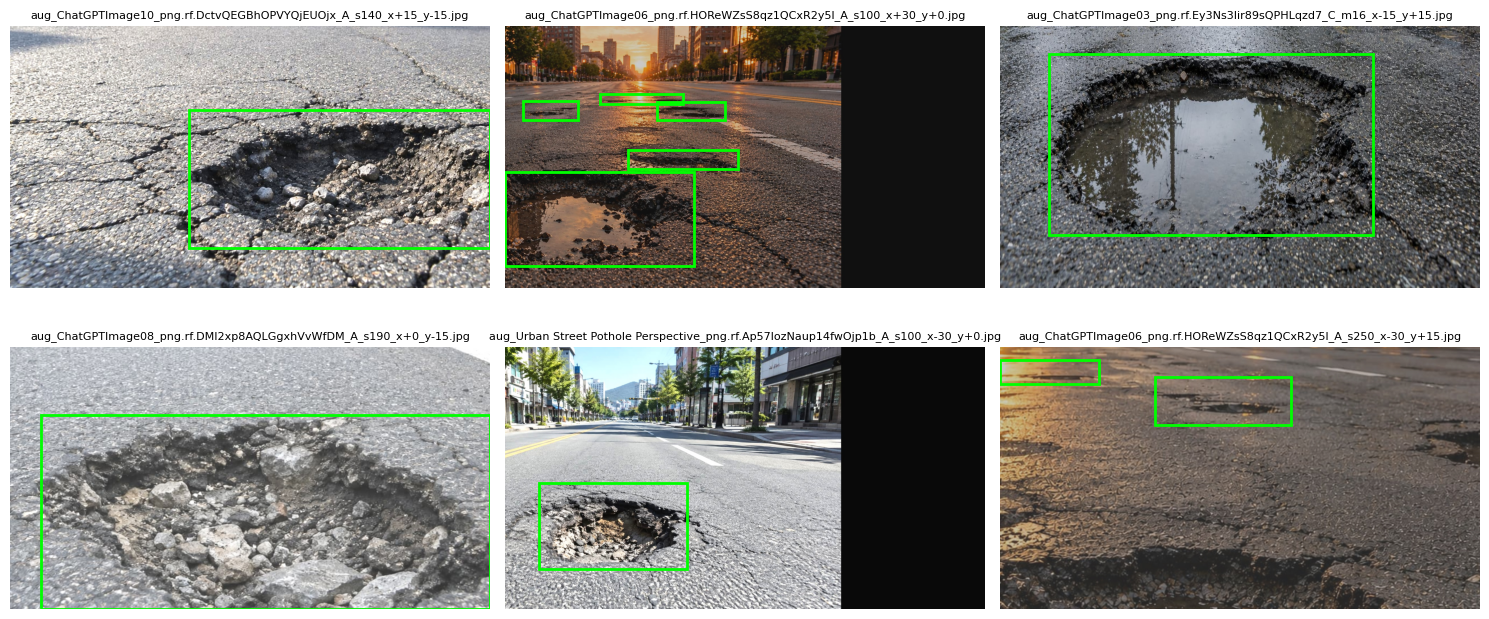

미리보기: /content/drive/MyDrive/KWU/DL/roadhazard/dataset_aug/preview_aug.png


In [22]:
# 셀 4. 눈으로 확인 - 증강 결과에 박스 그리기
sample = sorted(glob.glob(f"{OUT}/images/train/aug_*.jpg")) # 증강 이미지 전체 경로
sample = random.sample(sample, min(6, len(sample))) # 6개만
fig, axes = plt.subplots(2, 3, figsize=(15, 7)); axes = axes.ravel()
for ax, sp in zip(axes, sample):
  im = cv2.cvtColor(cv2.imread(sp), cv2.COLOR_BGR2RGB)
  H, W = im.shape[:2]
  ax.imshow(im); ax.axis("off")
  for c, cx, cy, w, h in read_yolo(label_path(sp)):
    x1, y1 = (cx-w/2)*W, (cy-h/2)*H
    ax.add_patch(plt.Rectangle((x1, y1), w*W, h*H, fill=False, edgecolor="lime", lw=2))
  ax.set_title(os.path.basename(sp), fontsize=8)
for ax in axes[len(sample):]: ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUT}/preview_aug.png", dpi = 110)
plt.show()
print("미리보기:", f"{OUT}/preview_aug.png")

In [23]:
print(f"""
[증강 완료 요약]
  입력(seed) : {SRC}
  출력(증강) : {OUT}/images/train, {OUT}/labels/train
  생성 장 수 : {made}장 (Affine {len(SCALES)}x{len(X_SHIFT)}x{len(Y_SHIFT)} + Crop {len(CROP_MARGINS)}x{len(X_SHIFT)}x{len(Y_SHIFT)})
  테스트는 seed와 겹치지 않는 '새로 생성한 이미지'로 할 것(데이터 누수 방지)
""")


[증강 완료 요약]
  입력(seed) : /content/drive/MyDrive/KWU/DL/roadhazard/dataset/roboflow_big
  출력(증강) : /content/drive/MyDrive/KWU/DL/roadhazard/dataset_aug/images/train, /content/drive/MyDrive/KWU/DL/roadhazard/dataset_aug/labels/train
  생성 장 수 : 1148장 (Affine 4x5x3 + Crop 3x5x3)
  테스트는 seed와 겹치지 않는 '새로 생성한 이미지'로 할 것(데이터 누수 방지)



In [ ]:
# 참고 셀. 조건을 바꿔 다시 돌리기 전에 이 셀을 먼저 실행해 이전 결과(예전 일본 증강본 포함)를 제거한 뒤 위 셀들을 처음부터 다시 실행
import shutil
OUT = "/content/drive/MyDrive/KWU/DL/roadeye.dataset_aug"
shutil.rmtree(OUT, ignore_errors=True)
os.makedirs(f"{OUT}/images/train", exist_ok=True); os.os.makedirs(f"{OUT}/labels/train", exist_ok=True)
print("dataset_aug 비움 → 이제 위 셀들을 처음부터 다시 실행하세요")